# Financial Econometrics I

#### High-frequency financial models II - Introduction to Realized Measures

by František Čech, based on previous years materials prepared by Jozef Baruník and Josef Kurka

#### Seminar 8: Summer Semester 2025/2026
___

In [4]:
library(rugarch)
library(repr)
options(repr.plot.width = 7, repr.plot.height = 4)
library(xts)

library(highfrequency)

## Jump diffusion model with stochastic volatility

Simulate model of stochastic volatility defined as

$$d X(t) = \left(\mu - \frac{\sigma^2(t)}{2}\right) dt + \sigma (t) d W_1(t) + c(t) d N(t)$$ 

$$d \sigma^2 (t) = \mathcal{K} (\alpha - \sigma^2(t)) dt + \gamma \sigma (t) d W_2 (t)$$
  
  $W_1 (t)$ and $W_2 (t)$ will be correlated Brownian motions.

In [5]:
start_date<-as.Date("2010-01-01")
end_date<-as.Date(Sys.time()) # today
days<-seq(from=start_date,to=end_date,by ="day")
biz_days<-as.POSIXlt(days)$wday
biz_days[biz_days==6|biz_days==0]<- NA
biz_days<-as.Date(na.omit(cbind(days,biz_days))[,1],origin="1970-01-01")

time_sim<- seq(from=as.POSIXct(paste(start_date,"9:00")),to=as.POSIXct(paste(start_date, "15:59")),by="min")
hh_mm<- format(time_sim, format = "%H:%M:%S")

In [6]:
head(time_sim)

[1] "2010-01-01 09:00:00 CET" "2010-01-01 09:01:00 CET"
[3] "2010-01-01 09:02:00 CET" "2010-01-01 09:03:00 CET"
[5] "2010-01-01 09:04:00 CET" "2010-01-01 09:05:00 CET"

In [7]:
TT = 1000
NN = 60 * 7
dt <- 1 / NN / 252
date_time<-unlist(lapply(1:TT, function(x) paste(rep(biz_days[x],NN),hh_mm)))

In [8]:
mu <- 0.05
kk <- 5
a <- 0.04
g <- 0.5
rho <- -0.5

In [9]:
W1 <- rnorm(TT * NN)
z <- rnorm(TT * NN)
W2 <- rho * W1 + sqrt(1 - rho^2) * z
J <- rnorm(TT * NN) * rpois(TT * NN, 2 / NN)

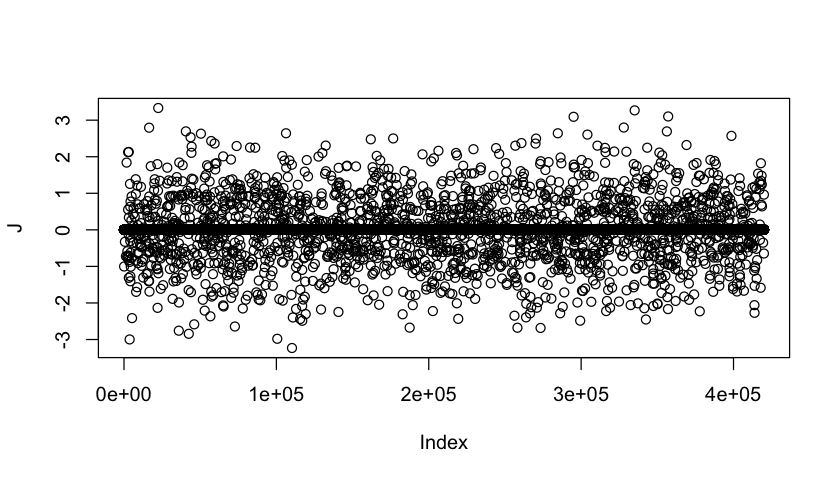

In [10]:
plot(J)

In [12]:
ret <- vector()
rettrue <- vector()
ret[1] <- 0
rettrue[1] <- 0
sigmasqr <- rchisq(1, (4 * kk * a) / g^2) / ((4 * kk) / g^2)

In [13]:
for (t in 2:(TT * NN)){
      ret[t] <- (mu - sigmasqr / 2) * dt + sqrt(sigmasqr * dt) * W2[t - 1] + J[t - 1] * sqrt(dt)
  rettrue[t] <- (mu - sigmasqr / 2) * dt + sqrt(sigmasqr * dt) * W2[t - 1]
  sigmasqr <- max(0, sigmasqr + kk * (a - sigmasqr) * dt + g * sqrt(sigmasqr * dt) * W1[t - 1])
}

ret_xts<-xts(x=ret,order.by = strptime(date_time, "%Y-%m-%d %H:%M"))
rettrue_xts<-xts(x=rettrue,order.by = strptime(date_time, "%Y-%m-%d %H:%M"))

In [14]:
daily <- unlist(lapply(lapply(1:TT, function (t){return(ret_xts[((t - 1) * NN + 1):(t * NN)])}), sum))
daily_xts<-xts(x=daily,order.by =unique(as.Date(index(ret_xts))))
dailytrue <- unlist(lapply(lapply(1:TT, function (t){return(rettrue_xts[((t - 1) * NN + 1):(t * NN)])}), sum))
dailytrue_xts<-xts(x=dailytrue,order.by =unique(as.Date(index(rettrue_xts))))

Why to use XTS? $\rightarrow$ easy filter - hours, days, months .....

In [15]:
head(ret_xts["T10:00/T10:59"],62)
ret_2011<-ret_xts["20110103"]
head(ret_2011)
tail(ret_2011)
#ret_2010_2012<-ret_xts["2010/2012"]
#ret_Jan_2011<-ret_xts["201101"]

                             [,1]
2010-01-01 10:00:00  4.433827e-04
2010-01-01 10:01:00  6.710559e-04
2010-01-01 10:02:00 -3.072655e-04
2010-01-01 10:03:00 -5.068910e-04
2010-01-01 10:04:00  2.641536e-04
2010-01-01 10:05:00  1.147446e-03
2010-01-01 10:06:00 -1.438642e-04
2010-01-01 10:07:00  9.474434e-05
2010-01-01 10:08:00  5.899874e-04
2010-01-01 10:09:00 -1.182372e-03
2010-01-01 10:10:00  1.820225e-03
2010-01-01 10:11:00 -4.861006e-04
2010-01-01 10:12:00 -1.082431e-03
2010-01-01 10:13:00 -1.250987e-03
2010-01-01 10:14:00 -1.750099e-04
2010-01-01 10:15:00  5.680884e-04
2010-01-01 10:16:00 -4.457209e-04
2010-01-01 10:17:00 -1.145430e-03
2010-01-01 10:18:00  5.442405e-04
2010-01-01 10:19:00  3.512972e-04
2010-01-01 10:20:00 -3.629866e-04
2010-01-01 10:21:00 -3.190962e-04
2010-01-01 10:22:00 -3.637319e-04
2010-01-01 10:23:00 -1.813845e-03
2010-01-01 10:24:00  4.389816e-04
2010-01-01 10:25:00 -1.406425e-03
2010-01-01 10:26:00 -1.762681e-04
2010-01-01 10:27:00 -1.093374e-03
2010-01-01 10:

                             [,1]
2011-01-03 09:00:00  3.139060e-04
2011-01-03 09:01:00 -2.034343e-04
2011-01-03 09:02:00  1.592027e-04
2011-01-03 09:03:00 -3.104547e-04
2011-01-03 09:04:00  9.595609e-05
2011-01-03 09:05:00 -5.626005e-05

                             [,1]
2011-01-03 15:54:00 -4.251749e-04
2011-01-03 15:55:00 -2.894778e-04
2011-01-03 15:56:00 -1.414188e-04
2011-01-03 15:57:00 -4.295232e-04
2011-01-03 15:58:00 -6.428018e-05
2011-01-03 15:59:00  6.655251e-05

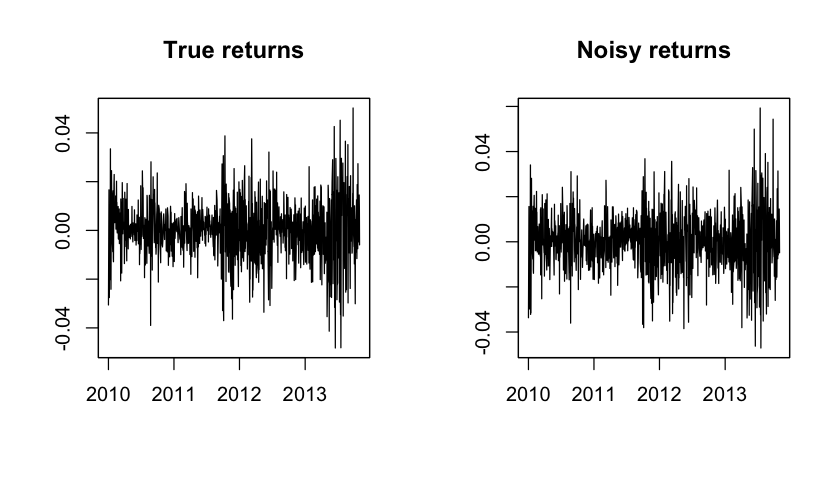

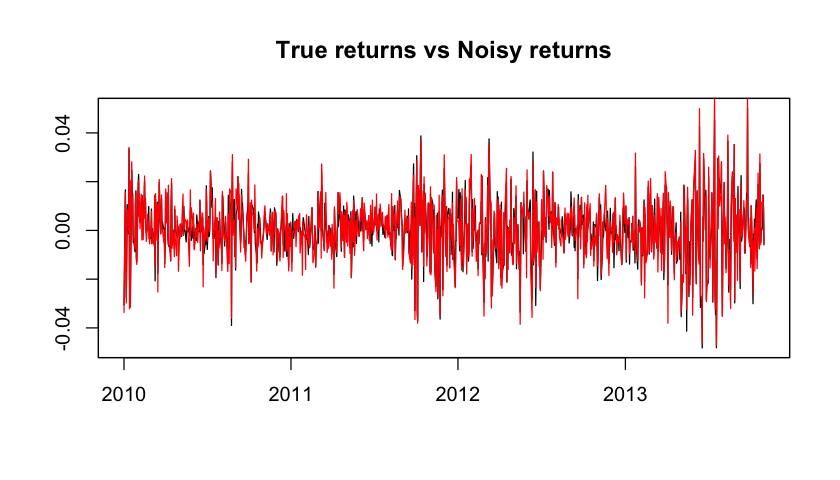

In [16]:
par(mfrow=c(1,2))
plot.zoo(dailytrue_xts, xlab = NA,ylab = NA, main = 'True returns')
plot.zoo(daily_xts,xlab = NA, ylab = NA, main = 'Noisy returns')

par(mfrow=c(1,1))
plot.zoo(dailytrue_xts, xlab = NA,ylab = NA, main = 'True returns vs Noisy returns')
lines(zoo(daily_xts),col="red")

Estimate volatility using Realized Variance.

In [17]:
RV <- unlist(lapply(lapply(1:TT, function (t){return(ret[((t - 1) * NN + 1):(t * NN)]^2)}), sum))
RV_xts<-xts(x=RV,order.by =unique(as.Date(index(ret_xts))))
RVtrue <- unlist(lapply(lapply(1:TT, function (t){return(rettrue[((t - 1) * NN + 1):(t * NN)]^2)}), sum))
RVtrue_xts<-xts(x=RVtrue,order.by =unique(as.Date(index(ret_xts))))

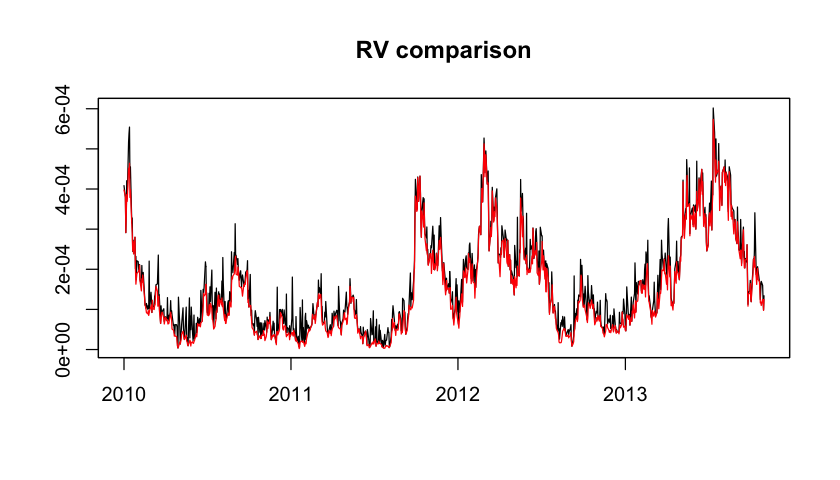

In [18]:
plot.zoo(RV_xts,xlab = NA, ylab = NA, main = 'RV comparison')
lines(zoo(RVtrue_xts), col = 'red', lwd = 1)

You can see how jumps greatly bias simple volatility estimator. Of course we have simulated the process so we know exactly its behavior, in the real world, it is harder to decide about jumps and see the effect of their impact on the estimated volatility.

Still, we can see that RV estimator estimates total quadratic variation.

Since we know how to use the simulations, we can use it to test, if our model estimated from the real-world data really works as it should.

### highfrequency package
When working with data we do not have to always "invent the wheel". Most probably somebody else already encounter similar problem as we, e.g. estimate realized variance, and most probably already found the solution.
https://cran.r-project.org/web/packages/highfrequency/highfrequency.pdf

In [19]:
RV_HF<-rCov(rData=ret_xts,cor=FALSE,align.by = NULL,makeReturns = FALSE)
head(RV_HF)

                            [,1]
2010-01-01 15:59:00 0.0004083579
2010-01-04 15:59:00 0.0003791501
2010-01-05 15:59:00 0.0002913063
2010-01-06 15:59:00 0.0003426348
2010-01-07 15:59:00 0.0004206668
2010-01-08 15:59:00 0.0003757577

In [20]:
index(RV_HF)<-as.Date(index(RV_HF))
head(RV_HF)

                   [,1]
2010-01-01 0.0004083579
2010-01-04 0.0003791501
2010-01-05 0.0002913063
2010-01-06 0.0003426348
2010-01-07 0.0004206668
2010-01-08 0.0003757577

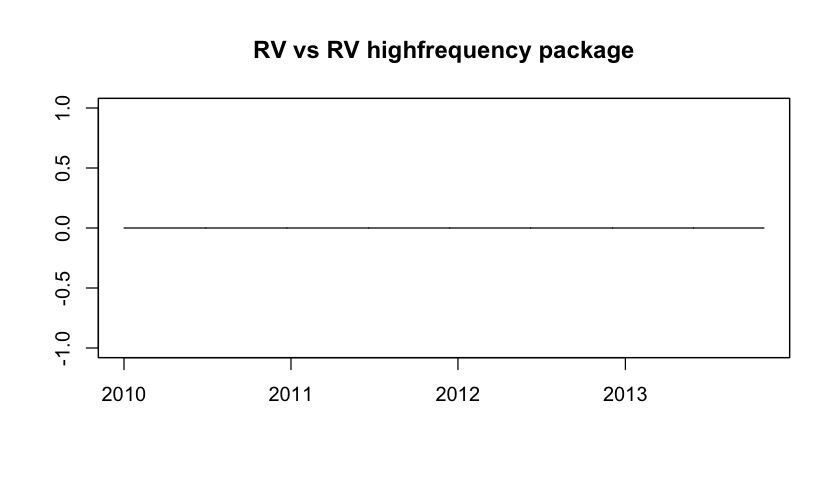

In [21]:
plot.zoo(RV_xts-RV_HF, xlab=NA, ylab=NA, main="RV vs RV highfrequency package")

### Bipower Variation

We will use Bipower Variation introduced in Barndorff-Nielsen and Shephard (2004) to estimate integrated volatility. Formulation of BPV ensures its robustness to jumps:

$$BPV_t = \frac{\pi}{2} \sum_{j = 2}^{m} \lvert r_{j-1} \rvert \lvert r_j \rvert,$$

where m is number of returns observations for day t.

In [22]:
BPV_BNS<- (pi/2)*unlist(lapply(lapply(1:TT, function (t){
  return(abs(as.numeric(ret_xts[((t - 1) * NN + 1):(t * NN - 1)])) * abs(as.numeric(ret_xts[((t - 1) * NN + 2):(t * NN)])))}),sum))
BPV_BNS_xts<-xts(x=BPV_BNS,order.by =unique(as.Date(index(ret_xts))))

In [23]:
BPV_BNS_alt<- (pi/2)*unlist(lapply(lapply(1:TT, function (t){
  return(abs(ret_xts[((t - 1) * NN + 1):(t * NN - 1)]) * abs(ret_xts[((t - 1) * NN + 2):(t * NN)]))}),sum))
BPV_BNS_alt_xts<-xts(x=BPV_BNS_alt,order.by =unique(as.Date(index(ret_xts))))

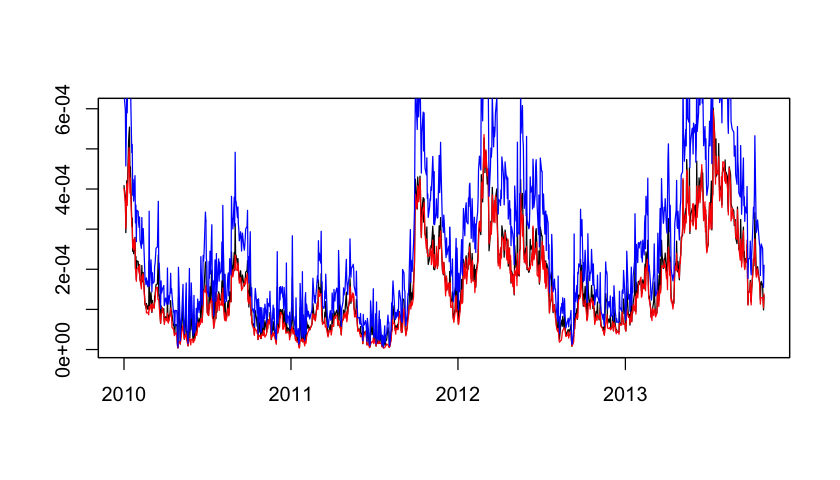

In [24]:
plot.zoo(RV_xts,xlab=NA,ylab=NA)
lines(zoo(BPV_BNS_xts),col="red")
lines(zoo(BPV_BNS_alt_xts),col="blue")

In [25]:
t=1
length(abs(ret_xts[((t - 1) * NN + 1):(t * NN - 1)])*
       abs(ret_xts[((t - 1) * NN + 2):(t * NN)]))

length(abs(as.numeric(ret_xts[((t - 1) * NN + 1):(t * NN - 1)]))*
       abs(as.numeric(ret_xts[((t - 1) * NN + 2):(t * NN)])))

[1] 418

[1] 419

In [26]:
length(abs(ret_xts[((t - 1) * NN + 1):(t * NN - 1)]))
length(abs(ret_xts[((t - 1) * NN + 2):(t * NN)]))
rm(t)      

[1] 419

[1] 419

similar to Realized Variance, we can obtain estimate of BPV using highfrequency package and function rBPCov

In [27]:
BPV_HF<-rBPCov(rData=ret_xts)
index(BPV_HF)<-as.Date(index(BPV_HF))

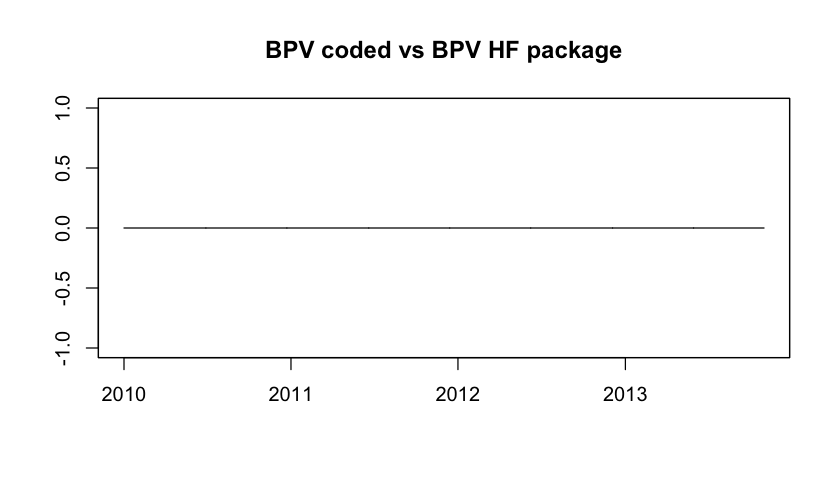

In [28]:
plot.zoo(BPV_BNS_xts-BPV_HF, xlab=NA, ylab=NA,main="BPV coded vs BPV HF package")

let's compare BPV and RV estimator

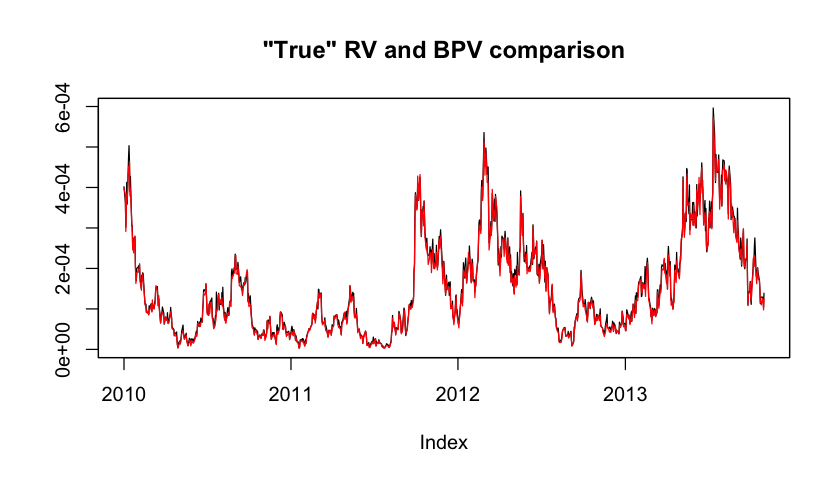

In [29]:
plot.zoo(BPV_HF, ylab = NA, main = '"True" RV and BPV comparison')
lines(zoo(RVtrue_xts), col = 'red', lwd = 1)

We can see that BPV estimates "true" volatility very precisely.

### Jumps

Construction of RV and BPV lets us estimate jumps simply as their difference. However, we need to distinguish true jumps from deviations caused by sampling noise

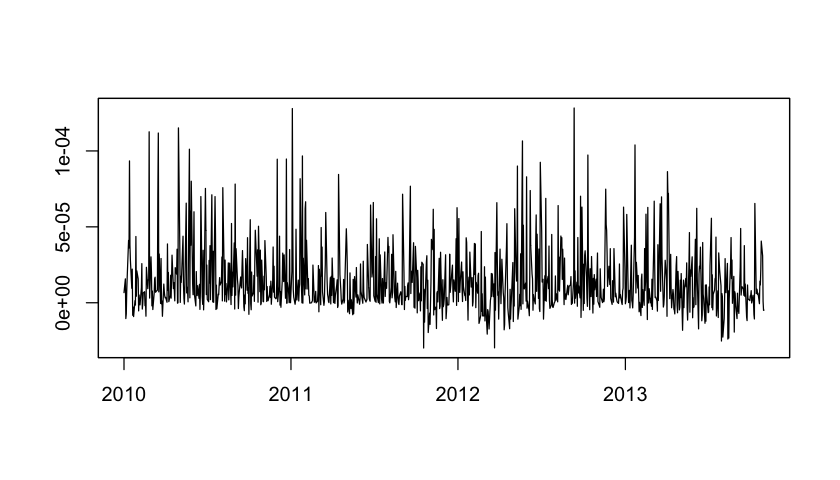

In [30]:
j_HF<-RV_HF-BPV_HF
plot.zoo(j_HF,xlab=NA,ylab=NA)

In [31]:
# jumps significance
jumps_test<- BNSjumpTest(ret_xts,IVestimator = "BV",IQestimator = "TP")
head(jumps_test)

                         ztest     lower    upper   p.value
2010-01-01 15:59:00  0.4315190 -1.959964 1.959964 0.6660910
2010-01-04 15:59:00  1.0919198 -1.959964 1.959964 0.2748684
2010-01-05 15:59:00 -0.9299568 -1.959964 1.959964 0.3523935
2010-01-06 15:59:00 -0.5747867 -1.959964 1.959964 0.5654356
2010-01-07 15:59:00  0.4795921 -1.959964 1.959964 0.6315175
2010-01-08 15:59:00  1.2731655 -1.959964 1.959964 0.2029593
                    universalThresholdLower universalThresholdUpper
2010-01-01 15:59:00               -2.522035                2.522035
2010-01-04 15:59:00               -2.522035                2.522035
2010-01-05 15:59:00               -2.522035                2.522035
2010-01-06 15:59:00               -2.522035                2.522035
2010-01-07 15:59:00               -2.522035                2.522035
2010-01-08 15:59:00               -2.522035                2.522035

In [32]:
I_HF <- sapply(1:TT, function (j) 
{if (jumps_test[j,"p.value"] < 0.05){1}
  else {0}})
J_HF <- j_HF * I_HF

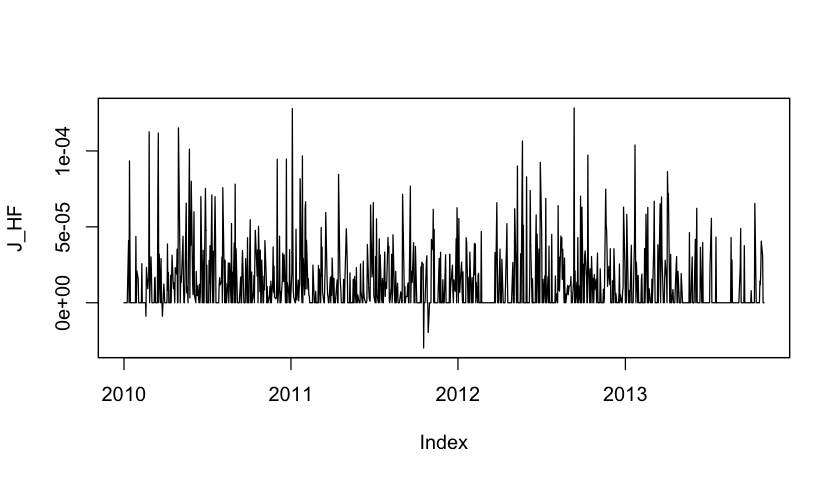

In [33]:
plot.zoo(J_HF)

In [34]:
sum(I_HF)

[1] 464

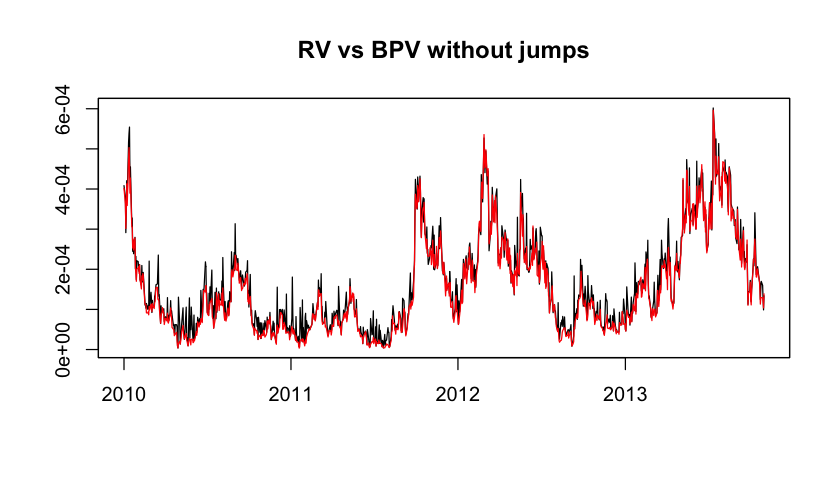

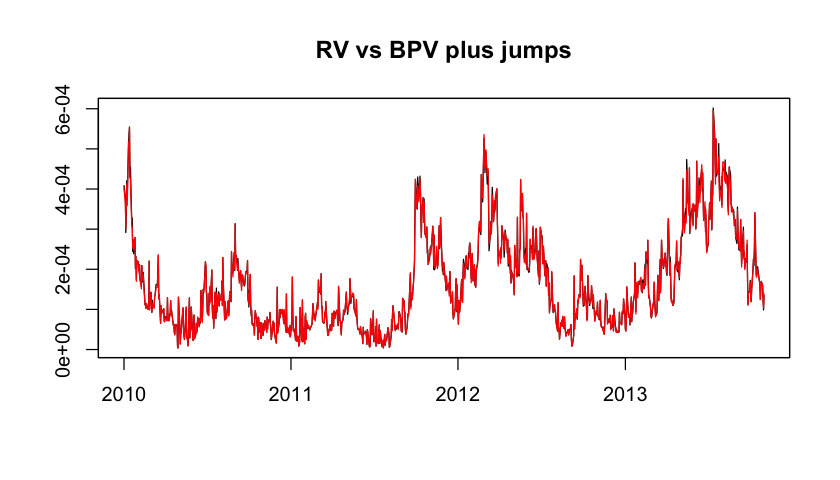

In [35]:
plot.zoo(RV_HF,xlab=NA, ylab = NA, main = 'RV vs BPV without jumps')
lines(zoo(BPV_HF), col = 'red', lwd = 1)

plot.zoo(RV_HF,xlab = NA,  ylab = NA, main = 'RV vs BPV plus jumps')
lines(zoo(BPV_HF + J_HF), col = 'red', lwd = 1)

### MedRV estimator of Andersen et al. (2012) - jump and noise robust
$$MedRV_t = \frac{\pi}{6-4\sqrt{3}+\pi}\frac{m}{m-2} \sum_{j = 2}^{m-1}med(\lvert r_{j-1} \rvert, \lvert r_j \rvert, \lvert r_{j+1} \rvert)^2,$$

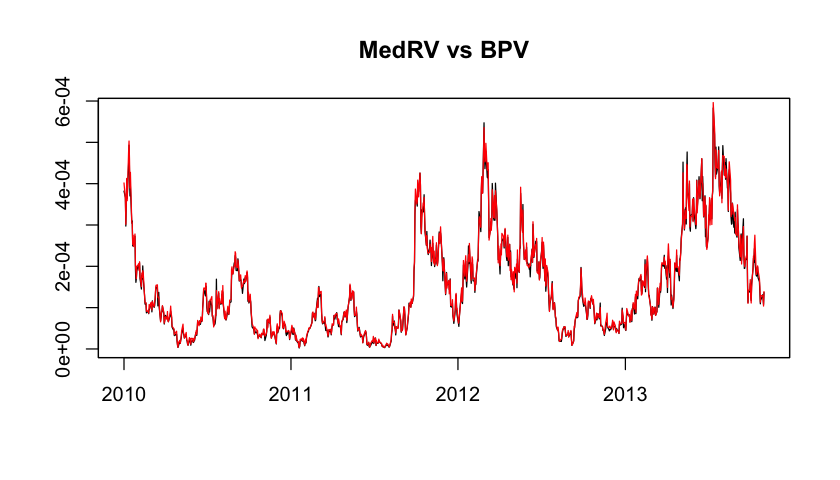

In [36]:
medRV_HF<-rMedRVar(rData=ret_xts)
index(medRV_HF)<-as.Date(index(medRV_HF))

plot.zoo(medRV_HF, xlab=NA, ylab=NA,main="MedRV vs BPV")
lines(zoo(BPV_HF),col="red")

In [37]:
# jumps
j_medRV_HF<-RV_HF-medRV_HF

# jumps significance
jumps_test_medRV<- BNSjumpTest(ret_xts,IVestimator = "rMedRVar",IQestimator = "rMedRQuar")

I_medRV_HF <- sapply(1:TT, function (j) 
{if (jumps_test_medRV[j,"p.value"] < 0.05){1}
  else {0}})
J_medRV_HF <- j_medRV_HF * I_medRV_HF

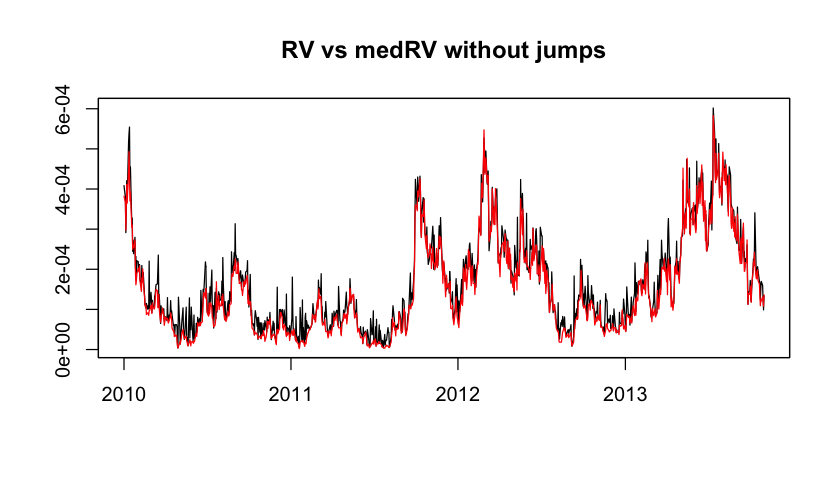

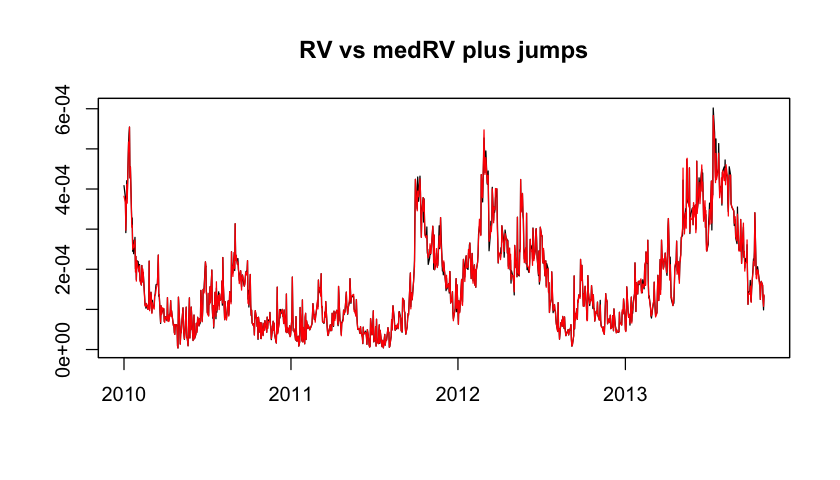

In [38]:
plot.zoo(RV_HF,xlab=NA, ylab = NA, main = 'RV vs medRV without jumps')
lines(zoo(medRV_HF), col = 'red', lwd = 1)

plot.zoo(RV_HF,xlab = NA,  ylab = NA, main = 'RV vs medRV plus jumps')
lines(zoo(medRV_HF + J_medRV_HF), col = 'red', lwd = 1)

### Bipower Variation - noise robust
introduced by Andersen et al (2011)

$$BPV(Andersen)_t = \frac{\frac{m}{m-2}}{(2 / \pi)} \sum_{j = 3}^{m} \lvert r_{j-2} \rvert \lvert r_j \rvert,$$

where m is number of returns observations for day t.

In [39]:
C <- (NN / (NN - 2)) / (2 / pi)
BPV_A <- unlist(lapply(lapply(1:TT, function (t){
  return(abs(as.numeric(ret_xts[((t - 1) * NN + 1):(t * NN - 2)])) * abs(as.numeric(ret_xts[((t - 1) * NN + 3):(t * NN)])))}), sum))
BPV_A <- BPV_A * C
BPV_A_xts<-xts(x=BPV_A,order.by =unique(as.Date(index(ret_xts))))

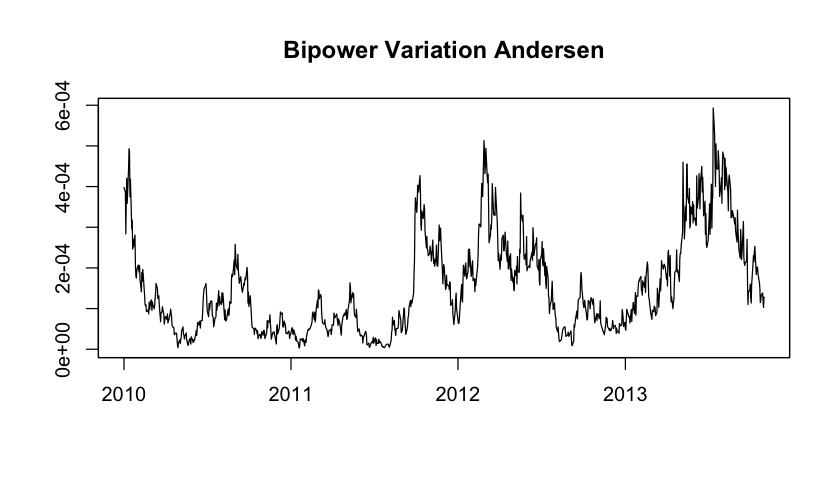

In [40]:
plot.zoo(BPV_A_xts,xlab=NA, ylab = NA, main = 'Bipower Variation Andersen')

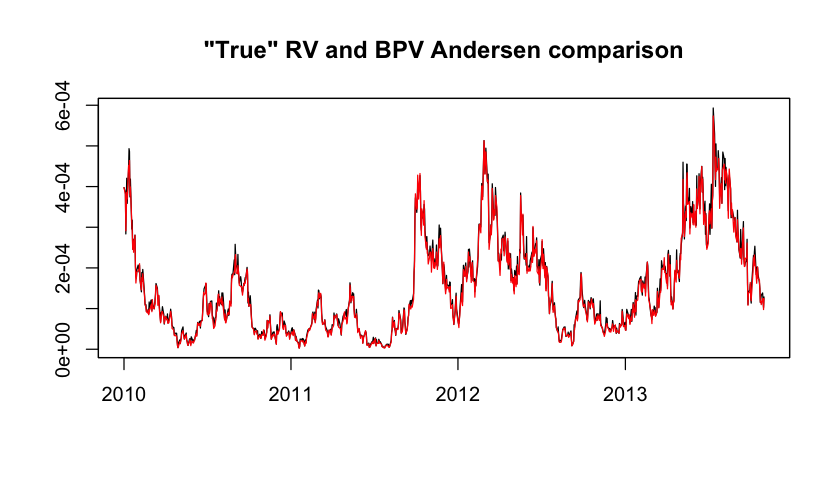

In [41]:
plot.zoo(BPV_A_xts,xlab=NA,  ylab = NA, main = '"True" RV and BPV Andersen comparison')
lines(zoo(RVtrue_xts), col = 'red', lwd = 1)

### Jumps - detection
Similar to work of Andersen et al (2011), we will use Z statistic to distinguish true jumps from deviations caused by sampling noise. First, compute the estimate of fourth moment

$$TQ_t = \frac{\frac{m^2}{m-4}}{(0.8313)^3} \sum_{j = 5}^m \lvert r_{j-4} \rvert^{4 / 3} \rvert r_{j-3} \rvert^{4 / 3} \rvert r_{j-2} \rvert^{4 / 3}$$ 

In [ ]:
L <- (NN^2) / (0.8313^3 * (NN - 4))
TQ <- unlist(lapply(lapply(1:TT, function (t){
  return(abs(as.numeric(ret_xts[((t - 1) * NN + 1):(t * NN - 4)]))^(4 / 3) * 
         abs(as.numeric(ret_xts[((t - 1) * NN + 2):(t * NN - 3)]))^(4 / 3) * 
         abs(as.numeric(ret_xts[((t - 1) * NN + 3):(t * NN - 2)]))^(4 / 3))}), sum))
TQ <- TQ * L
TQ_xts<-xts(x=TQ,order.by =unique(as.Date(index(ret_xts))))

Now, the Z statistic is formalized as

$$Z_t = \frac{\frac{RV_t - BPV_t}{RV_t}}{\sqrt{(((\pi / 2)^2 + \pi - 5) / m) * max(1, TQ_t / BPV_t)}},$$

where $max(1, TQ_t / BPV_t)$ is the small sample refinement of the fourth moment.

Hence, jump variation for day t will be

$$JV_t = I_{Z_t > \Phi (\alpha)} (RV_t - BPV_t),$$

where $\Phi (\alpha)$ is a critical value from $N(0, 1)$ distribution.

In [ ]:
j <- RV_xts - BPV_A_xts
Z <- (j / RV_xts) / sqrt((((pi / 2)^2 + pi - 5) / NN) * unlist(lapply(1:TT, function (i) 
{max(1, TQ_xts[i] / BPV_A_xts[i]^2)})))

In [ ]:
hist(Z, col = 'yellow 3', breaks = 20, main = NA)
box()

Form the indicator function for 95% significance level.

In [ ]:
proc <- 5
I5 <- sapply(1:TT, function (j) 
{if (Z[j] > qnorm(1 - (proc / (2 * 100)), lower.tail = TRUE)) {1}
  else {0}})
sum(I5)

In [ ]:
J5 <- j * I5
plot(zoo(J5), type = 'h', lwd = 3, ylim = c(0, max(J5) * 1.2),xlab=NA, ylab=NA)
legend("top", legend = c('95% significance'),
       col = c('black'), lwd = 2, bty = 'n', cex = 0.8)

In [ ]:
plot.zoo(RV_xts, ylab = NA, main = 'RV against BPV Andersen without jumps')
lines(zoo(BPV_A_xts), col = 'red', lwd = 1)

plot.zoo(RV_xts, ylab = NA, main = 'RV against BPV Andersen plus jumps')
lines(zoo(BPV_A_xts + J5), col = 'red', lwd = 1)

Hence, we have decomposed quadratic variation to volatility and jumps!!!

## Model volatility with GARCH

Estimate volatility via a GARCH model, specifically GARCH(1,1) and GARCH(1,1)-M models

In [42]:
garchspec1 <- ugarchspec(mean.model = list(armaOrder = c(0, 0)),variance.model = list(garchOrder = c(1, 1)))
garchvol1 <- ugarchfit(garchspec1, daily_xts)

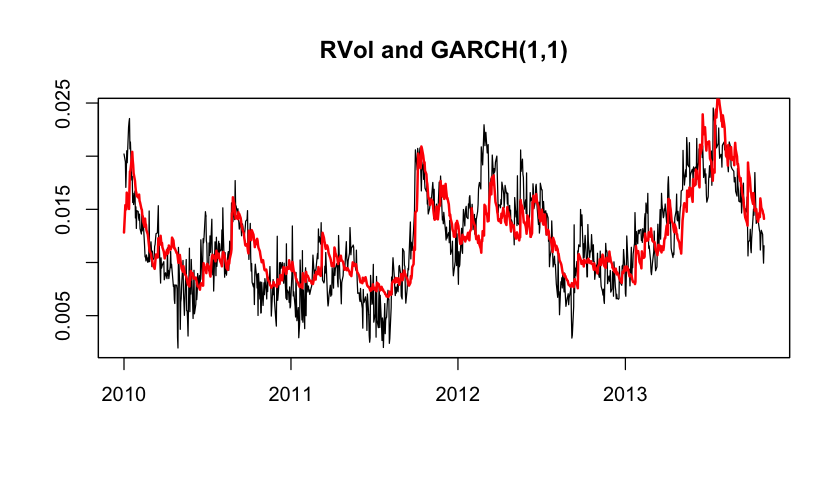

In [43]:
plot.zoo(sqrt(RV_HF),xlab=NA, ylab = NA, main = 'RVol and GARCH(1,1)')
lines(zoo(sigma(garchvol1)), col = 'red', lwd = 2)

In [44]:
garchspecm1 <- ugarchspec(variance.model=list(model = "sGARCH", garchOrder = c(1, 1)),
                          mean.model = list(armaOrder=c(0, 0), include.mean=TRUE, archm = TRUE, archpow = 1))

garchvolm1 <- ugarchfit(garchspecm1, daily_xts)

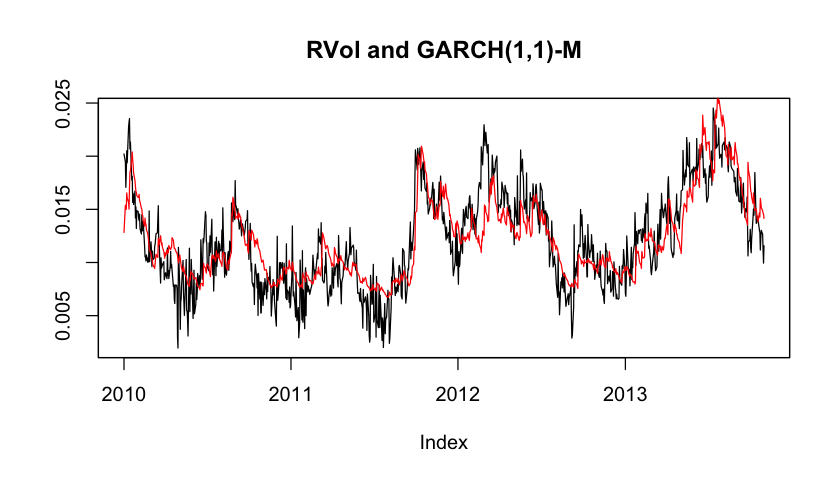

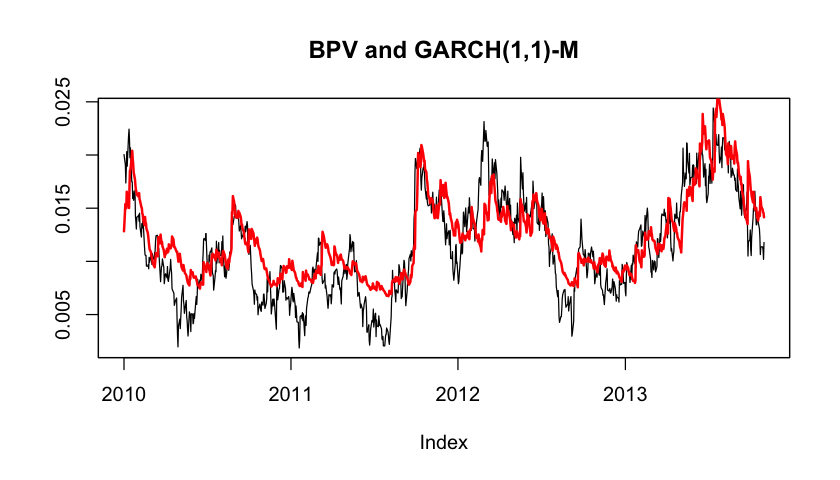

In [45]:
plot.zoo(sqrt(RV_HF), ylab = NA, main = 'RVol and GARCH(1,1)-M')
lines(zoo(sigma(garchvolm1)), col = 'red', lwd = 1)

plot.zoo(sqrt(BPV_HF), ylab = NA, main = 'BPV and GARCH(1,1)-M')
lines(zoo(sigma(garchvolm1)), col = 'red', lwd = 2)

### Working with high-frequency data

In [47]:
library(fst)

also installing the dependency ‘fstcore’





The downloaded binary packages are in
	/var/folders/cg/v8_xfn_j3qz270dg852c49ym0000gn/T//RtmpcOlXs3/downloaded_packages


In [48]:
sample_data<-read.fst(path = "sample_data.fst")
sample_data_xts<-xts(sample_data$V2,order.by = sample_data$V1)
rm(sample_data)

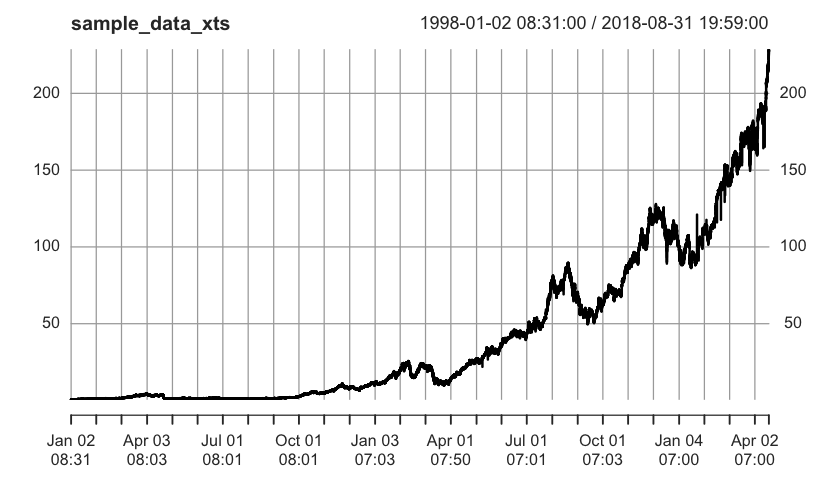

In [49]:
plot(sample_data_xts)

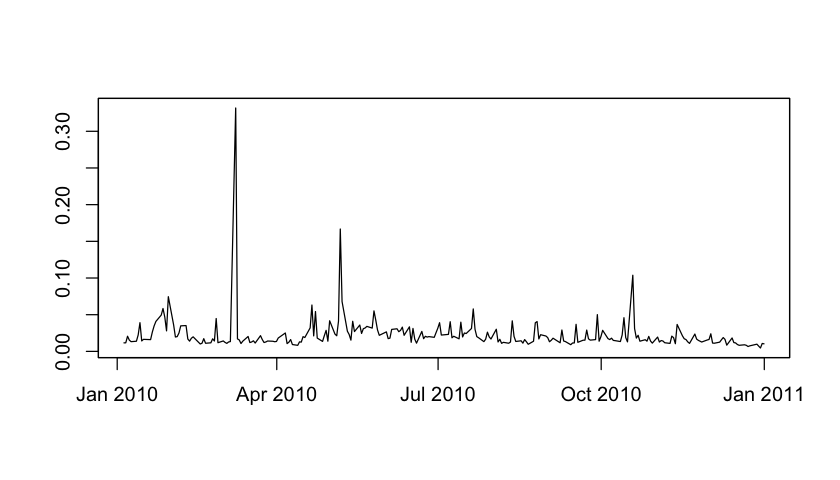

In [50]:
sample_data_2010<-sample_data_xts["2010"]
RV_sample_data_1min<-rCov(rData = sample_data_2010,makeReturns = TRUE)
plot.zoo(sqrt(RV_sample_data_1min),xlab=NA,ylab=NA)

In [51]:
RV_sample_data_5min<-rCov(rData = sample_data_2010,makeReturns = TRUE,alignBy = "mins",alignPeriod = 5)

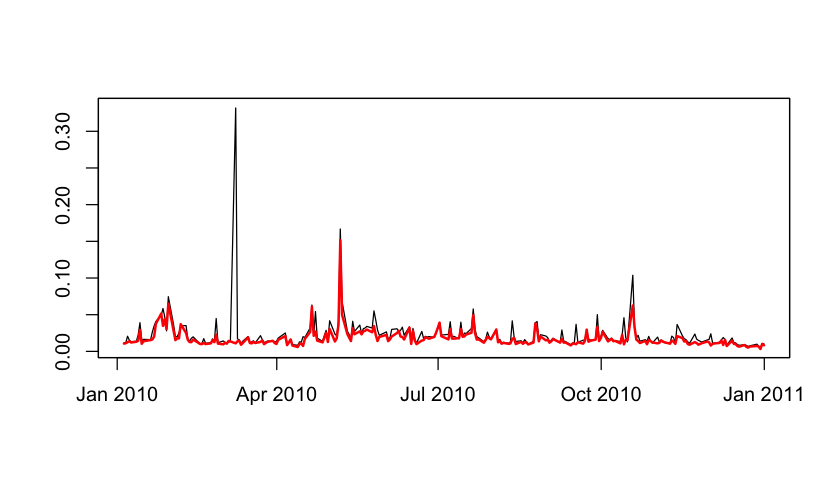

In [52]:
plot.zoo(sqrt(RV_sample_data_1min),xlab=NA,ylab=NA)
lines(zoo(sqrt(RV_sample_data_5min)),col="red",xlab=NA,ylab=NA,lwd=2)

In [53]:
sample_data_2010_5min<-aggregateTS(sample_data_2010,alignBy = "minutes",alignPeriod = 5)
RV_sample_data_5min_data<-rCov(sample_data_2010_5min,makeReturns = TRUE)

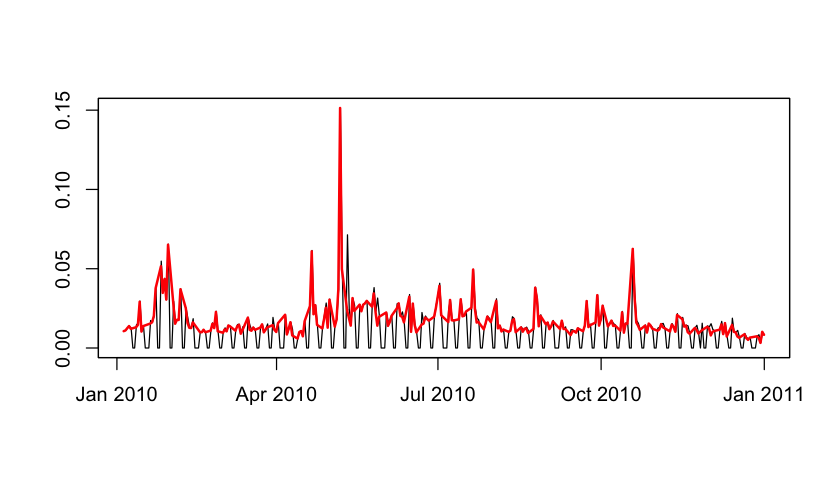

In [54]:
plot.zoo(sqrt(RV_sample_data_5min_data),xlab=NA,ylab=NA)
lines(zoo(sqrt(RV_sample_data_5min)),col="red",xlab=NA,ylab=NA,lwd=2)

Warning message in as.numeric(RV_sample_data_5min_data) - as.numeric(RV_sample_data_5min):
“longer object length is not a multiple of shorter object length”


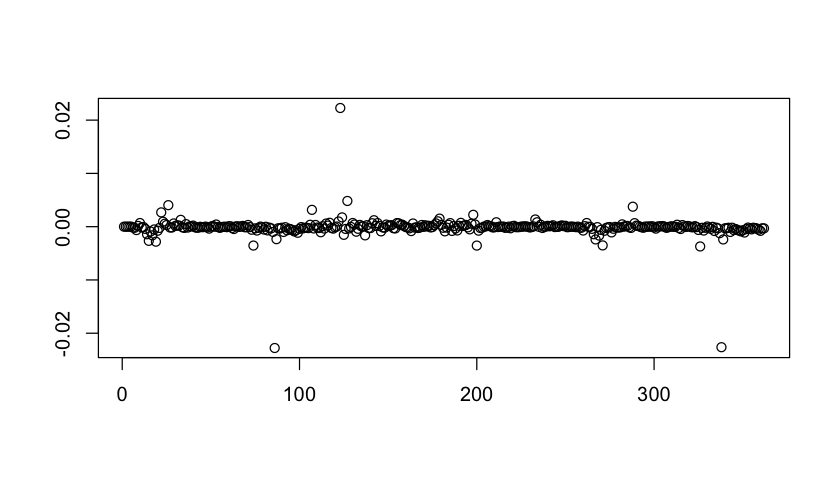

In [55]:
plot(as.numeric(RV_sample_data_5min_data)-as.numeric(RV_sample_data_5min),xlab=NA,ylab=NA)

there might be problem with data aggregation so let´s have closer look at single day

In [56]:
sample_data_day_1min<-sample_data_2010["20100104"]
sample_data_day_5min_v1<-aggregateTS(sample_data_day_1min,alignBy = "minutes",alignPeriod = 5)
sample_data_day_5min_v2<-aggregateTS(sample_data_day_1min,alignBy = "minutes",alignPeriod = 5,dropna = TRUE)
sample_data_day_compare<-merge(sample_data_day_1min,sample_data_day_5min_v1,sample_data_day_5min_v2)

In [57]:
head(sample_data_day_compare,50)

Warning message:
“object timezone ('UTC') is different from system timezone ('')
  NOTE: set 'options(xts_check_TZ = FALSE)' to disable this warning
    This note is displayed once per session”


                    sample_data_day_1min sample_data_day_5min_v1       x
2010-01-04 07:00:00              26.8776                 26.8776      NA
2010-01-04 07:02:00              26.9663                      NA      NA
2010-01-04 07:05:00                   NA                 26.9663 26.9663
2010-01-04 07:06:00              26.9663                      NA      NA
2010-01-04 07:07:00              26.9675                      NA      NA
2010-01-04 07:09:00              26.9675                      NA      NA
2010-01-04 07:10:00                   NA                 26.9675 26.9675
2010-01-04 07:15:00                   NA                 26.9675      NA
2010-01-04 07:17:00              26.9675                      NA      NA
2010-01-04 07:20:00                   NA                 26.9675 26.9675
2010-01-04 07:25:00                   NA                 26.9675      NA
2010-01-04 07:26:00              26.9422                      NA      NA
2010-01-04 07:27:00              26.9473           

In [58]:
sample_data_day_1min_sec<-sample_data_day_1min
index(sample_data_day_1min_sec)<-index(sample_data_day_1min_sec)-1
sample_data_day_5min_sec_v1<-aggregateTS(sample_data_day_1min_sec,alignBy = "minutes",alignPeriod = 5)
sample_data_day_5min_sec_v2<-aggregateTS(sample_data_day_1min_sec,alignBy = "minutes",alignPeriod = 5,dropna = TRUE)
sample_data_day_compare_sec<-merge(sample_data_day_1min,sample_data_day_5min_sec_v1,sample_data_day_5min_sec_v2)

In [59]:
head(sample_data_day_compare_sec,50)

Warning message:
“object timezone ('UTC') is different from system timezone ('')”


                    sample_data_day_1min sample_data_day_5min_sec_v1       x
2010-01-04 06:55:00                   NA                     26.8776      NA
2010-01-04 07:00:00              26.8776                     26.8776 26.8776
2010-01-04 07:02:00              26.9663                          NA      NA
2010-01-04 07:05:00                   NA                     26.9663 26.9663
2010-01-04 07:06:00              26.9663                          NA      NA
2010-01-04 07:07:00              26.9675                          NA      NA
2010-01-04 07:09:00              26.9675                          NA      NA
2010-01-04 07:10:00                   NA                     26.9675 26.9675
2010-01-04 07:15:00                   NA                     26.9675      NA
2010-01-04 07:17:00              26.9675                          NA      NA
2010-01-04 07:20:00                   NA                     26.9675 26.9675
2010-01-04 07:25:00                   NA                     26.9675      NA

check how it works when we move data by 1 sec

In [60]:
sample_data_2010_sec<-sample_data_xts["2010"]
index(sample_data_2010_sec)<-index(sample_data_2010_sec)-1
head(sample_data_2010_sec)

Warning message:
“object timezone ('UTC') is different from system timezone ('')”


                       [,1]
2010-01-04 06:59:59 26.8776
2010-01-04 07:01:59 26.9663
2010-01-04 07:05:59 26.9663
2010-01-04 07:06:59 26.9675
2010-01-04 07:08:59 26.9675
2010-01-04 07:16:59 26.9675

In [61]:
RV_sample_data_5min_sec<-rCov(rData = sample_data_2010_sec,makeReturns = TRUE,alignBy = "mins",alignPeriod = 5)

In [62]:
sample_data_2010_5min_sec<-aggregateTS(sample_data_2010_sec,alignBy = "minutes",alignPeriod = 5,dropna = TRUE)
RV_sample_data_5min_sec_data<-rCov(sample_data_2010_5min_sec,makeReturns = TRUE)

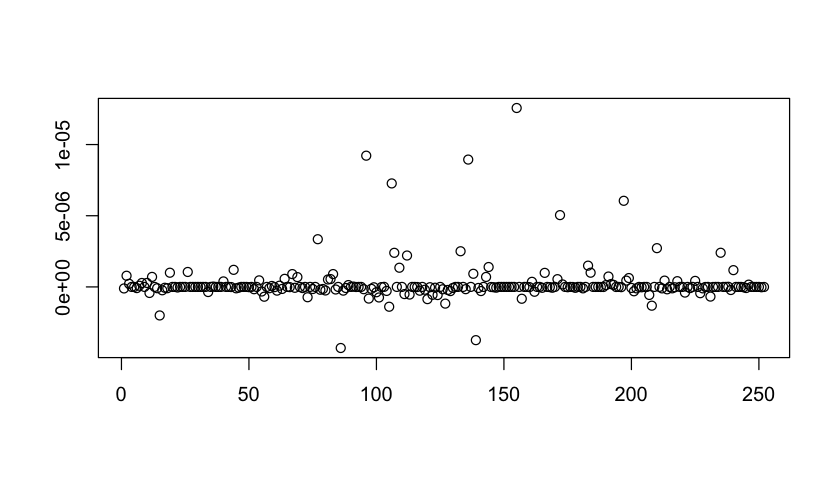

In [63]:
plot(as.numeric(RV_sample_data_5min_sec)-as.numeric(RV_sample_data_5min_sec_data),xlab=NA,ylab=NA)